In [38]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load("lyhennetty_data3.npy") # data on kompleksimuodossa ja datapisteitä on 4096 kpl
pit = len(data)
Fs = 1000000
Ts = 1/Fs
Fsym = 10000
Tsym = 1/Fsym
t = np.arange(0,pit*Ts,Ts)
f = 200000
j = complex(0,1)
kertoja = np.exp(-j*2*np.pi*f*t)

sekoitettu = data * kertoja


#1. sekoita alas 200 kHz (ei tarvitse suodattaa)
#2. Tulosta sekoitettua signaalia, näet miten pyörii
#3. korjaa taajuusvirhe, kunnes signaali "pysähtyy"
#4. Korjaa vaihevirhe, signaali asettuu x-akselin suuntaan
#5. Tee bittipäätökset Tsym välein. Selvitä, mitä ovat ne 16 viimeistä bittiä

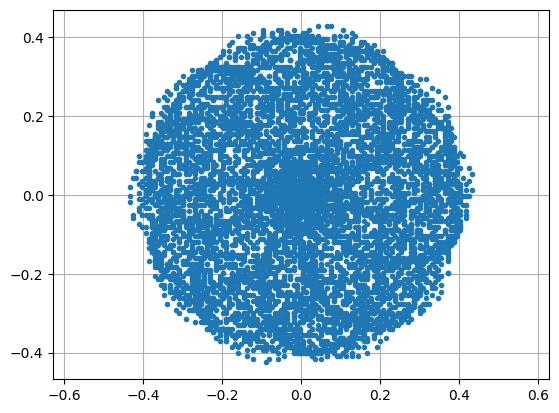

In [34]:
plt.plot(data.real, data.imag, '.')
plt.axis('equal')
plt.grid()
plt.show()

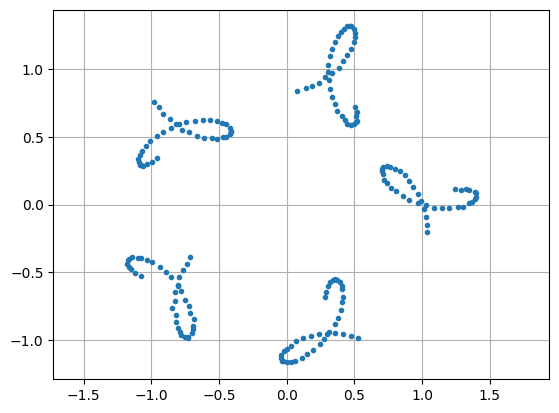

In [35]:
naytemaara = 200

plt.plot(sekoitettu.real[0:200], sekoitettu.imag[0:200], '.')
plt.axis('equal')
plt.grid()
plt.show()

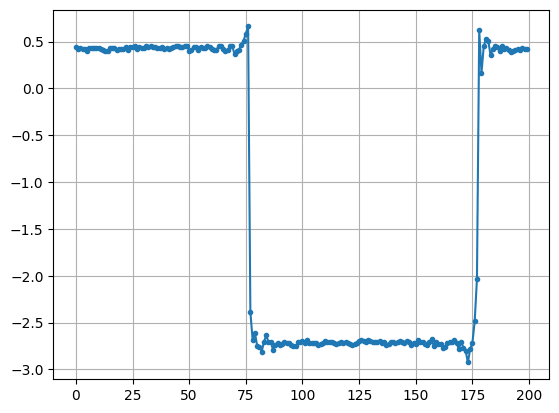

In [48]:
luku = ( -0.2 - 0.45) / 70

taajuusvirhe = (luku * Fs) / (2 * np.pi)

taajuuskorjaus = np.exp(-j * 2*np.pi * taajuusvirhe * t)

korjattu = sekoitettu * taajuuskorjaus

vaihe = np.unwrap(np.angle(korjattu))

plt.plot(vaihe[:200], '.-')
plt.grid()
plt.show()

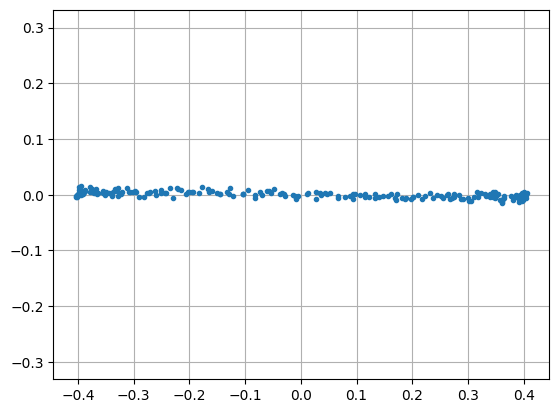

In [53]:
y = 0.17
x = 0.36

vaihe_virhe = np.arctan2(y, x)

vaihekorjaus = np.exp(-j * vaihe_virhe)

vaihekorjattu = korjattu * vaihekorjaus

plt.plot(vaihekorjattu.real[:200], vaihekorjattu.imag[:200], '.')
plt.axis('equal')
plt.grid()
plt.show()

[1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
1010110011001100010011110100101110101010101011001100110001001111010010111010101010
32


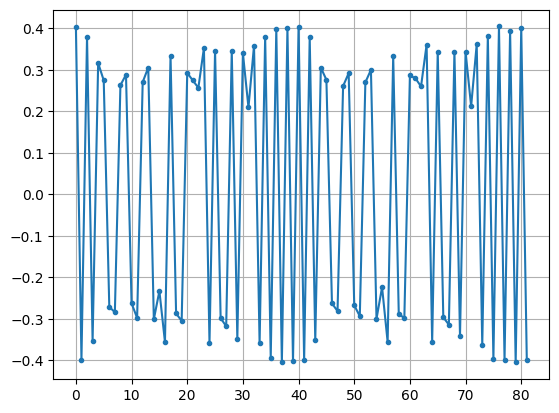

In [66]:
samples_per_symbol = Fs//Fsym

start = 25

bitit = [1 if x > 0 else 0 for x in vaihekorjattu.real[start::samples_per_symbol]]

print(bitit)

bittijono = ''.join(str(bit) for bit in bitit)
print(bittijono)

preamble = "101010101010"

kohta = bittijono.find(preamble)
print(kohta)

plt.plot(vaihekorjattu.real[start::samples_per_symbol], '.-')
plt.grid()
plt.show()

In [72]:
preamble_alku = kohta
sync_alku = preamble_alku + 12
data_alku = sync_alku + 12

data = bittijono[data_alku:data_alku + 16]

first_byte = data[:8]
second_byte = data[8:]

print(bittijono[preamble_alku:preamble_alku + 12])
print(bittijono[sync_alku:sync_alku + 12])
print(bittijono[data_alku:data_alku + 16])

print(f"{first_byte=}")
print(f"{second_byte=}")
print(f"{chr(int(first_byte,2))}")
print(f"{chr(int(second_byte,2))}")

101010101010
110011001100
0100111101001011
first_byte='01001111'
second_byte='01001011'
O
K
